**Sub questions:**
- (a) Manually select 6 corresponding points, compute homography, warp c1 to perspective of c2
- (b) Subtract warped image from c2 to find differences. Display difference image
- (c) Use SIFT to find keypoints and descriptors, match them, display the matches
- (d) Compute homography from SIFT matches, warp and difference compare with (a) and (b)

**Images:** `c1.jpg`, `c2.jpg`


In [1]:
import sys
print("Python:", sys.executable)

import cv2 as cv
import numpy as np
import matplotlib.pyplot as plt
import os
print("cv2   :", cv.__version__)
print("numpy :", np.__version__)

# Load both circuit board images
im1 = cv.imread('../images/c1.jpg', cv.IMREAD_REDUCED_COLOR_4)
im2 = cv.imread('../images/c2.jpg', cv.IMREAD_REDUCED_COLOR_4)
assert im1 is not None, "Could not load c1.jpg — check the path"
assert im2 is not None, "Could not load c2.jpg — check the path"

print(f"c1 size  : {im1.shape[1]} x {im1.shape[0]} px")
print(f"c2 size  : {im2.shape[1]} x {im2.shape[0]} px")


Python: C:\Users\user\AppData\Local\Programs\Python\Python313\python.exe
cv2   : 4.13.0
numpy : 2.4.4
c1 size  : 570 x 683 px
c2 size  : 579 x 626 px


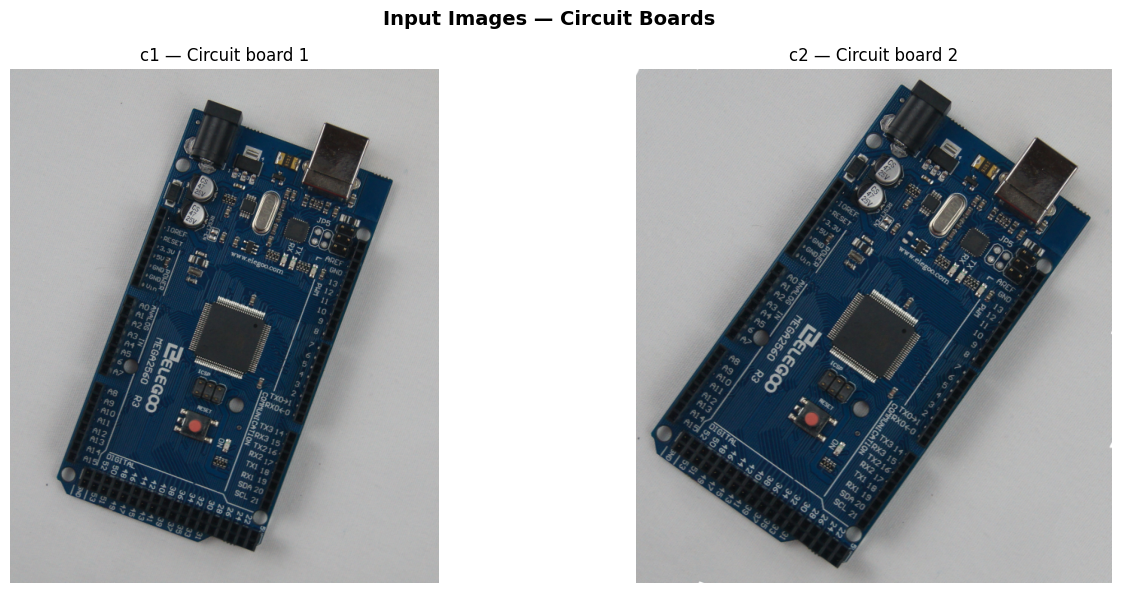

In [2]:
# Display both circuit board images side by side
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle('Input Images — Circuit Boards', fontsize=14, fontweight='bold')

axes[0].imshow(cv.cvtColor(im1, cv.COLOR_BGR2RGB))
axes[0].set_title('c1 — Circuit board 1', fontsize=12)
axes[0].axis('off')

axes[1].imshow(cv.cvtColor(im2, cv.COLOR_BGR2RGB))
axes[1].set_title('c2 — Circuit board 2', fontsize=12)
axes[1].axis('off')

plt.tight_layout()
os.makedirs('../outputs/q3', exist_ok=True)
plt.savefig('../outputs/q3/q3_input_images.png', dpi=150, bbox_inches='tight')
plt.show()


## (a) Manual Homography

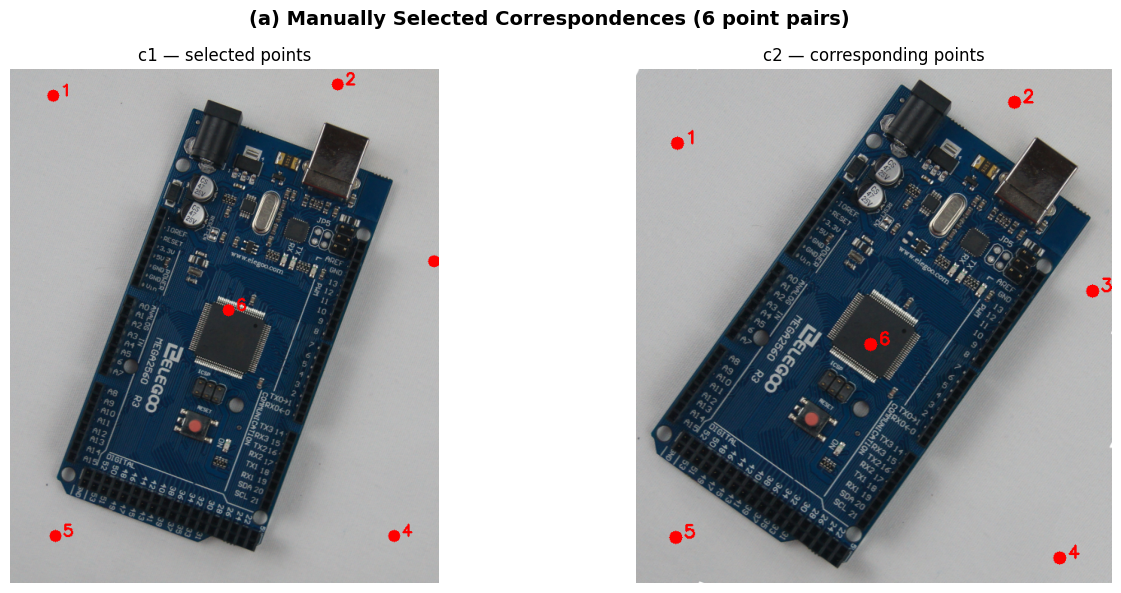

In [3]:
# Manually selected corresponding points
p1 = np.float32([
    [ 57,  35],    # top-left  
    [435,  20],    # top-right 
    [563, 255],    # right-side 
    [510, 620],    # bottom-right 
    [ 60, 620],    # bottom-left 
    [290, 320],    # center
])

p2 = np.float32([
    [ 50,  90],    # top-left
    [460,  40],    # top-right
    [555, 270],    # right-side
    [515, 595],    # bottom-right
    [ 48, 570],    # bottom-left
    [285, 335],    # center
])

# Visualise selected points on both images
im1_pts = im1.copy()
im2_pts = im2.copy()

for idx in range(len(p1)):
    cv.circle(im1_pts, (int(p1[idx, 0]), int(p1[idx, 1])), 8, (0, 0, 255), -1)
    cv.putText(im1_pts, str(idx + 1),
               (int(p1[idx, 0]) + 10, int(p1[idx, 1])),
               cv.FONT_HERSHEY_SIMPLEX, 0.7, (0, 0, 255), 2)

    cv.circle(im2_pts, (int(p2[idx, 0]), int(p2[idx, 1])), 8, (0, 0, 255), -1)
    cv.putText(im2_pts, str(idx + 1),
               (int(p2[idx, 0]) + 10, int(p2[idx, 1])),
               cv.FONT_HERSHEY_SIMPLEX, 0.7, (0, 0, 255), 2)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle('(a) Manually Selected Correspondences (6 point pairs)', fontsize=14, fontweight='bold')

axes[0].imshow(cv.cvtColor(im1_pts, cv.COLOR_BGR2RGB))
axes[0].set_title('c1 — selected points', fontsize=12)
axes[0].axis('off')

axes[1].imshow(cv.cvtColor(im2_pts, cv.COLOR_BGR2RGB))
axes[1].set_title('c2 — corresponding points', fontsize=12)
axes[1].axis('off')

plt.tight_layout()
plt.savefig('../outputs/q3/q3a_manual_points.png', dpi=150, bbox_inches='tight')
plt.show()


Homography H (manual points):
[[ 6.17342513e-01 -1.56906022e-01  9.63257644e+01]
 [-1.46347287e-01  4.34000696e-01  1.68204808e+02]
 [-3.16154367e-04 -3.69788110e-04  1.00000000e+00]]


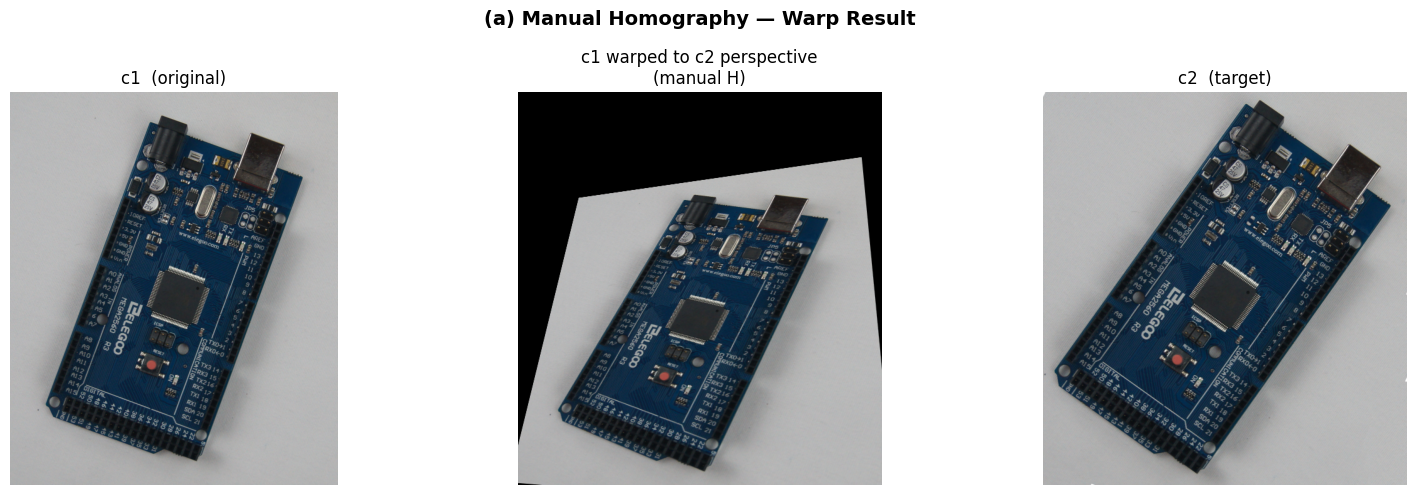

In [4]:
# Compute homography from manual point pairs
H_manual, mask_manual = cv.findHomography(p1, p2, cv.RANSAC)

print("Homography H (manual points):")
print(H_manual)

# Warp c1 to the perspective of c2
h2, w2 = im2.shape[:2]
im1_warped_manual = cv.warpPerspective(im1, H_manual, (w2, h2))

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle('(a) Manual Homography — Warp Result', fontsize=14, fontweight='bold')

axes[0].imshow(cv.cvtColor(im1, cv.COLOR_BGR2RGB))
axes[0].set_title('c1  (original)', fontsize=12)
axes[0].axis('off')

axes[1].imshow(cv.cvtColor(im1_warped_manual, cv.COLOR_BGR2RGB))
axes[1].set_title('c1 warped to c2 perspective\n(manual H)', fontsize=12)
axes[1].axis('off')

axes[2].imshow(cv.cvtColor(im2, cv.COLOR_BGR2RGB))
axes[2].set_title('c2  (target)', fontsize=12)
axes[2].axis('off')

plt.tight_layout()
plt.savefig('../outputs/q3/q3a_warp_manual.png', dpi=150, bbox_inches='tight')
plt.show()


## (b) Difference Image — Manual Homography

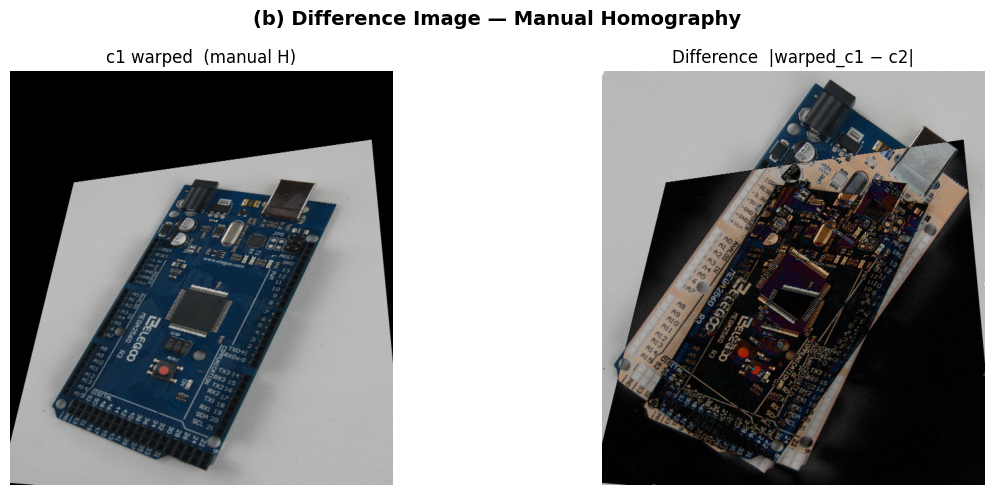

Diff image — mean: 73.90  |  max: 255


In [5]:
# Compute absolute difference
diff_manual = np.abs(im1_warped_manual.astype(np.float32) -
                     im2.astype(np.float32)).astype(np.uint8)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle('(b) Difference Image — Manual Homography', fontsize=14, fontweight='bold')

axes[0].imshow(cv.cvtColor(im1_warped_manual, cv.COLOR_BGR2RGB))
axes[0].set_title('c1 warped  (manual H)', fontsize=12)
axes[0].axis('off')

axes[1].imshow(cv.cvtColor(diff_manual, cv.COLOR_BGR2RGB))
axes[1].set_title('Difference  |warped_c1 − c2|', fontsize=12)
axes[1].axis('off')

plt.tight_layout()
plt.savefig('../outputs/q3/q3b_diff_manual.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"Diff image — mean: {diff_manual.mean():.2f}  |  max: {diff_manual.max()}")


## (c) SIFT Feature Matching

In [6]:
# Convert to grayscale for SIFT
img1_gray = cv.cvtColor(im1, cv.COLOR_BGR2GRAY)
img2_gray = cv.cvtColor(im2, cv.COLOR_BGR2GRAY)

# Initiate SIFT detector
sift = cv.SIFT_create()

# Find keypoints and descriptors with SIFT
kp1, des1 = sift.detectAndCompute(img1_gray, None)
kp2, des2 = sift.detectAndCompute(img2_gray, None)

print(f"Keypoints in c1 : {len(kp1)}")
print(f"Keypoints in c2 : {len(kp2)}")

# FLANN matcher
FLANN_INDEX_KDTREE = 1
index_params  = dict(algorithm=FLANN_INDEX_KDTREE, trees=5)
search_params = dict(checks=50)
flann   = cv.FlannBasedMatcher(index_params, search_params)
matches = flann.knnMatch(des1, des2, k=2)

# Lowe's ratio test
matchesMask = [[0, 0] for i in range(len(matches))]
for i, (m, n) in enumerate(matches):
    if m.distance < 0.7 * n.distance:
        matchesMask[i] = [1, 0]

good_count = sum(1 for mask in matchesMask if mask[0] == 1)
print(f"Total raw matches           : {len(matches)}")
print(f"Good matches (ratio = 0.7)  : {good_count}")


Keypoints in c1 : 1439
Keypoints in c2 : 1489
Total raw matches           : 1439
Good matches (ratio = 0.7)  : 1018


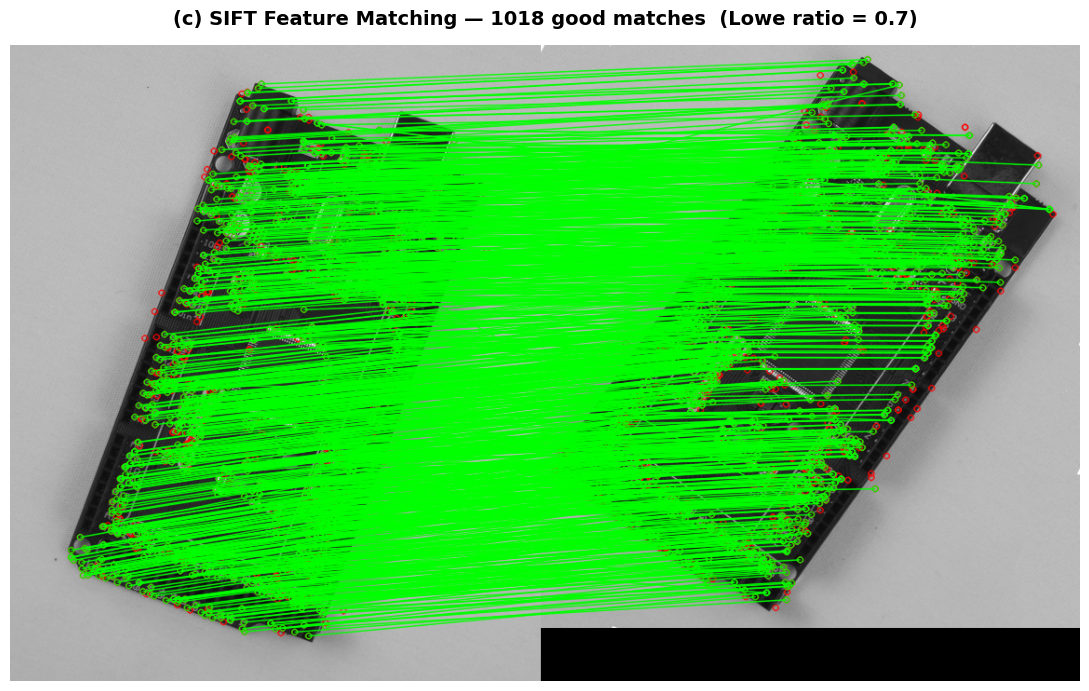

In [7]:
# Draw matches
draw_params = dict(matchColor=(0, 255, 0),
                   singlePointColor=(255, 0, 0),
                   matchesMask=matchesMask,
                   flags=cv.DrawMatchesFlags_DEFAULT)

img_matches = cv.drawMatchesKnn(img1_gray, kp1, img2_gray, kp2,
                                matches, None, **draw_params)

fig, ax = plt.subplots(1, 1, figsize=(16, 7))
fig.suptitle(f'(c) SIFT Feature Matching — {good_count} good matches  (Lowe ratio = 0.7)',
             fontsize=14, fontweight='bold')

ax.imshow(img_matches)
ax.axis('off')

plt.tight_layout()
plt.savefig('../outputs/q3/q3c_sift_matches.png', dpi=150, bbox_inches='tight')
plt.show()


## (d) Homography from SIFT Matches — Warp, Diff, and Comparison

In [8]:
# Extract point coordinates from good matches
pts1_sift = []
pts2_sift = []
for i, (m, n) in enumerate(matches):
    if matchesMask[i][0] == 1:
        pts1_sift.append(kp1[m.queryIdx].pt)
        pts2_sift.append(kp2[m.trainIdx].pt)

pts1_sift = np.float32(pts1_sift)
pts2_sift = np.float32(pts2_sift)

# Compute homography from SIFT matches
# RANSAC internally filters any remaining outlier matches
H_sift, mask_sift = cv.findHomography(pts1_sift, pts2_sift, cv.RANSAC)
inliers_sift = int(mask_sift.sum())

print(f"SIFT homography — {inliers_sift} inliers used out of {len(pts1_sift)} good matches")
print()
print("Homography H (SIFT):")
print(H_sift)

# Warp c1 using SIFT-based homography
im1_warped_sift = cv.warpPerspective(im1, H_sift, (w2, h2))

# Difference image
diff_sift = np.abs(im1_warped_sift.astype(np.float32) -
                   im2.astype(np.float32)).astype(np.uint8)

print(f"Diff (manual) — mean: {diff_manual.mean():.2f}  |  max: {diff_manual.max()}")
print(f"Diff (SIFT)   — mean: {diff_sift.mean():.2f}  |  max: {diff_sift.max()}")


SIFT homography — 987 inliers used out of 1018 good matches

Homography H (SIFT):
[[ 9.64679361e-01 -2.63839015e-01  1.01518702e+02]
 [ 2.63883879e-01  9.64738844e-01 -9.60601827e+01]
 [ 2.66009703e-07  6.59565676e-08  1.00000000e+00]]
Diff (manual) — mean: 73.90  |  max: 255
Diff (SIFT)   — mean: 16.35  |  max: 255


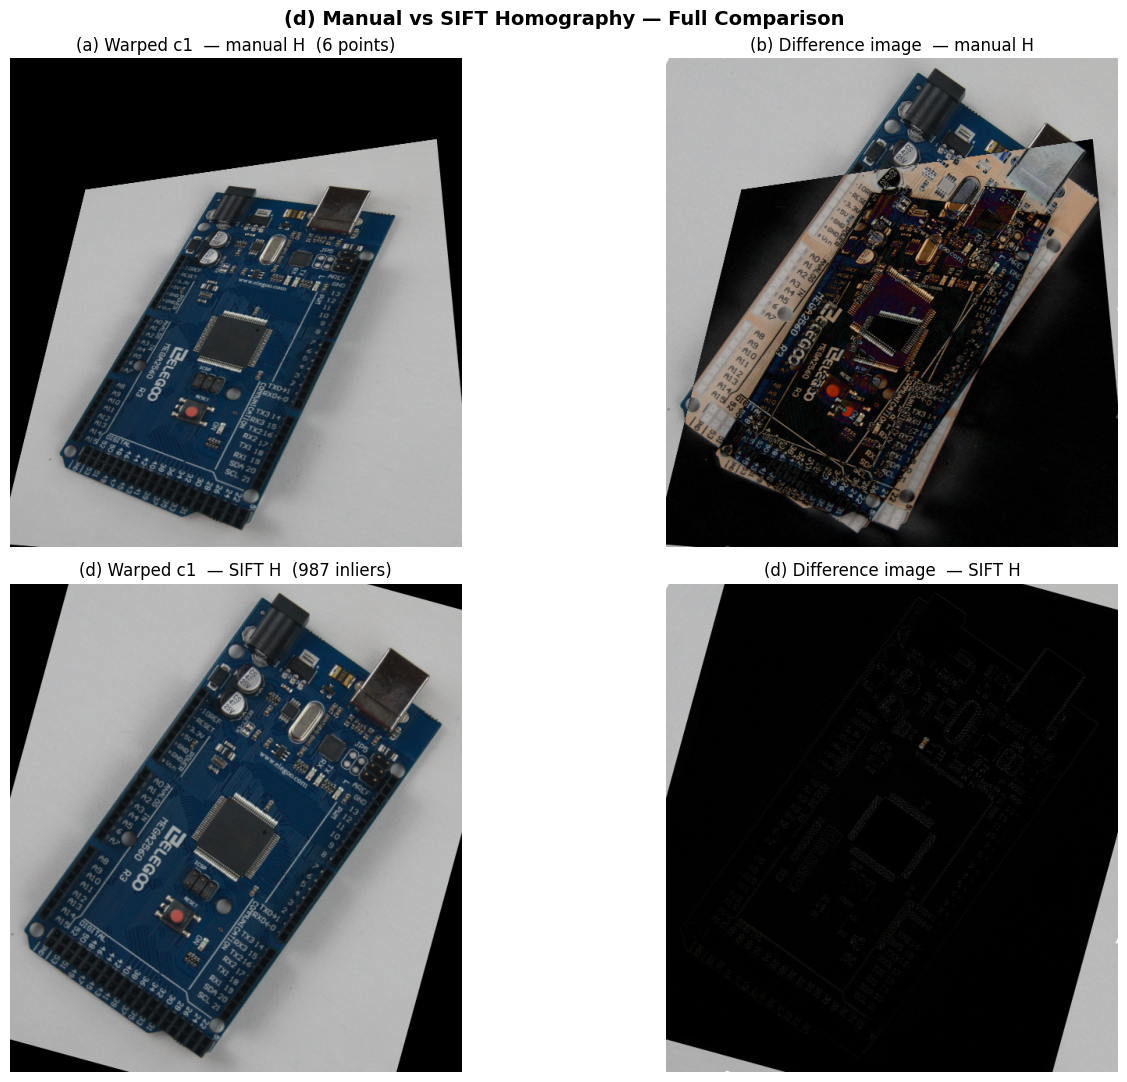

In [9]:
# Side-by-side comparison: manual vs SIFT
fig, axes = plt.subplots(2, 2, figsize=(15, 11))
fig.suptitle('(d) Manual vs SIFT Homography — Full Comparison', fontsize=14, fontweight='bold')

axes[0, 0].imshow(cv.cvtColor(im1_warped_manual, cv.COLOR_BGR2RGB))
axes[0, 0].set_title('(a) Warped c1  — manual H  (6 points)', fontsize=12)
axes[0, 0].axis('off')

axes[0, 1].imshow(cv.cvtColor(diff_manual, cv.COLOR_BGR2RGB))
axes[0, 1].set_title('(b) Difference image  — manual H', fontsize=12)
axes[0, 1].axis('off')

axes[1, 0].imshow(cv.cvtColor(im1_warped_sift, cv.COLOR_BGR2RGB))
axes[1, 0].set_title(f'(d) Warped c1  — SIFT H  ({inliers_sift} inliers)', fontsize=12)
axes[1, 0].axis('off')

axes[1, 1].imshow(cv.cvtColor(diff_sift, cv.COLOR_BGR2RGB))
axes[1, 1].set_title('(d) Difference image  — SIFT H', fontsize=12)
axes[1, 1].axis('off')

plt.tight_layout()
plt.savefig('../outputs/q3/q3d_comparison.png', dpi=150, bbox_inches='tight')
plt.show()


In [10]:
# Summary statistics
print(f"{'Method':<25} {'Correspondences':>18} {'Diff Mean':>12} {'Diff Max':>10}")
print("-" * 68)
print(f"{'Manual homography':<25} {'6 hand-picked pts':>18} "      f"{diff_manual.mean():>12.2f} {diff_manual.max():>10}")
print(f"{'SIFT homography':<25} {str(inliers_sift) + ' RANSAC inliers':>18} "      f"{diff_sift.mean():>12.2f} {diff_sift.max():>10}")
print()
print("Discussion:")
print("  SIFT diff mean is lower than manual  →  SIFT warp aligns more accurately.")
print("  Manual H uses 6 sparse points with ~5-10px human click error.")
print("  SIFT H uses", inliers_sift, "sub-pixel accurate correspondences spread")
print("  across the whole image — giving a much tighter geometric estimate.")
print("  Remaining diff intensity reflects lighting differences between shots")
print("  and JPEG compression artifacts, not geometric misalignment.")


Method                       Correspondences    Diff Mean   Diff Max
--------------------------------------------------------------------
Manual homography          6 hand-picked pts        73.90        255
SIFT homography           987 RANSAC inliers        16.35        255

Discussion:
  SIFT diff mean is lower than manual  →  SIFT warp aligns more accurately.
  Manual H uses 6 sparse points with ~5-10px human click error.
  SIFT H uses 987 sub-pixel accurate correspondences spread
  across the whole image — giving a much tighter geometric estimate.
  Remaining diff intensity reflects lighting differences between shots
  and JPEG compression artifacts, not geometric misalignment.
